In [2]:
# import matplotlib.pyplot as plt
#
# def plot_attention_pattern(attention, layer, head):
#     plt.imshow(attention, #use blue-red cmap
#                cmap='coolwarm',
#                interpolation='nearest')
#     plt.colorbar()
#     plt.title(f"Attention Pattern - Layer {layer}, Head {head}")
#     plt.xlabel("Key Position")
#     plt.ylabel("Query Position")
#     plt.show()

In [3]:
# import matplotlib.pyplot as plt
#
# def plot_attention_patterns(positive_attention, negative_attention, layer, head):
#     fig, axs = plt.subplots(1, 2, figsize=(12, 6))
#     fig.suptitle(f"Attention Patterns - Layer {layer}, Head {head}")
#
#     # Plot positive attention
#     axs[0].imshow(positive_attention, cmap='coolwarm', interpolation='nearest')
#     axs[0].set_title("Positive Attention")
#     axs[0].set_xlabel("Key Position")
#     axs[0].set_ylabel("Query Position")
#
#     # Plot negative attention
#     axs[1].imshow(negative_attention, cmap='coolwarm', interpolation='nearest')
#     axs[1].set_title("Negative Attention")
#     axs[1].set_xlabel("Key Position")
#     axs[1].set_ylabel("Query Position")
#
#     # plt.colorbar(ax=axs[0])
#     # plt.colorbar(ax=axs[1])
#     plt.show()

In [23]:
from cProfile import label

import torch
import numpy as np
import math
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoConfig, Qwen2ForCausalLM

N_SEQUENCES = 50
# N_SEQUENCES = 1
N_MAX_SEARCHED_SEQUENCES = 500
# N_MAX_SEARCHED_SEQUENCES = 50
N_TOKENS = 1000
# N_TOKENS = 200

N_LAYERS = 24
N_HEADS = 7
N_SAMPLE = 100
# N_SAMPLE = 50

global model_name


def get_inputs(dataset, model_tokenizer):
    sequences = [dataset['train'][i]['text'] for i in range(N_MAX_SEARCHED_SEQUENCES)]# tokenize the sequence
    inputs_pre = [model_tokenizer(sequences[i], return_tensors="pt", truncation=True, max_length=N_TOKENS) for i in range(N_MAX_SEARCHED_SEQUENCES)]
    inputs_post = []
    for i in range(N_MAX_SEARCHED_SEQUENCES):
        if inputs_pre[i]['input_ids'].shape[1] == N_TOKENS and len(inputs_post) < N_SEQUENCES:
            inputs_post.append(inputs_pre[i])

    assert len(inputs_post) == N_SEQUENCES

    return inputs_post


def get_attn(model, inputs):
    model.eval()

    batch_inputs = {k: torch.cat([inp[k] for inp in inputs], dim=0) for k in inputs[0]}

    with torch.no_grad():
        outputs = model(**batch_inputs, output_attentions=True)

    if model_name != "qwen2_vanilla":
        positive_attentions = torch.stack(
            [attn[0][:, :, N_TOKENS - N_SAMPLE:, :] for attn in outputs.attentions],
            dim=1
        )
        negative_attentions = torch.stack(
            [attn[1][:, :, N_TOKENS - N_SAMPLE:, :] for attn in outputs.attentions],
            dim=1
        )

        return positive_attentions, negative_attentions
    else:
        attentions = torch.stack(
            [attn[:, :, N_TOKENS - N_SAMPLE:, :] for attn in outputs.attentions],
            dim=1
        )
        return attentions, _


def calculate_token_distributions(positive_attentions, negative_attentions):

    distributions = torch.zeros(N_SEQUENCES, N_SAMPLE, N_LAYERS, N_HEADS * 2, N_TOKENS)

    for sequence in range(N_SEQUENCES):
        for token in range(N_SAMPLE):
            for layer in range(N_LAYERS):
                for head in range(N_HEADS):
                    positive_attention = positive_attentions[sequence][layer][head][token]
                    distributions[sequence][token][layer][head] = positive_attention
                    if model_name != "qwen2_vanilla":
                        negative_attention = negative_attentions[sequence][layer][head][token]
                        distributions[sequence][token][layer][head + N_HEADS] = negative_attention
                    else:
                        positive_attention2 = positive_attentions[sequence][layer][head + N_HEADS][token]
                        distributions[sequence][token][layer][head + N_HEADS] = positive_attention2

    return distributions


def calculate_statistical_distances(distributions):
    # Assume distributions has shape: (n_seq, n_sample, n_layers, 2*n_heads, n_tokens)
    # and these distributions are normalized along the last dimension.
    n_seq, n_sample, n_layers, n_heads2, n_tokens = distributions.shape

    # Preallocate distances tensor: shape (n_seq, n_sample, n_layers, 2*n_heads, 2*n_heads)
    distances = torch.empty(n_seq, n_sample, n_layers, n_heads2, n_heads2, device=distributions.device)

    for token in range(n_sample):
        # Determine current truncation length
        L = n_tokens - n_sample + token + 1
        # Select truncated distributions for current token for all sequences, layers, and heads
        # p_cur shape: (n_seq, n_layers, 2*n_heads, L)
        p_cur = distributions[:, token, :, :, :L]
        # Expand dimensions to compute pairwise divergence:
        # p_exp shape: (n_seq, n_layers, 2*n_heads, 1, L)
        # q_exp shape: (n_seq, n_layers, 1, 2*n_heads, L)
        p_exp = p_cur.unsqueeze(3)
        q_exp = p_cur.unsqueeze(2)
        # Compute total variation distance
        tvd = 0.5 * torch.sum(torch.abs(p_exp - q_exp), dim=-1)
        # tvd is of shape (n_seq, n_layers, 2*n_heads, 2*n_heads); assign it to the proper token position
        distances[:, token, :, :, :] = tvd

    return distances


def calculate_average_distances(distances, draw=False):

    average_correspondings = []
    average_positive_positives = []
    average_positive_negatives = []
    average_negative_negatives = []

    # average_distances = torch.mean(distances, dim=0).mean(dim=0).mean(dim=0)
    #
    # plot the average distances with numbers in squares with inverse color
    # plt.imshow(average_distances, cmap='coolwarm', interpolation='nearest')
    # plt.colorbar()
    # for i in range(average_distances.shape[0]):
    #     for j in range(average_distances.shape[1]):
    #         plt.text(j, i, f"{average_distances[i][j]:.2f}", ha='center', va='center', color='black')
    #
    # plt.title("Average Total Variance Distance")
    # plt.xlabel("Head")
    # plt.ylabel("Head")
    # plt.show()

    for layer in range(N_LAYERS):
        average_distances = torch.mean(distances[:, :, layer], dim=0).mean(dim=0)

        if draw:
            # plot the average distances with numbers in squares with inverse color
            plt.figure(figsize=(10, 10))
            plt.imshow(average_distances, cmap='coolwarm', interpolation='nearest', vmin=0, vmax=1)
            plt.colorbar()
            for i in range(average_distances.shape[0]):
                for j in range(average_distances.shape[1]):
                    plt.text(j, i, f"{average_distances[i][j]:.2f}", ha='center', va='center', color='black', fontsize=12)

            plt.title(f"Average Total Variance Distance: Layer {layer}")
            # plt.xlabel("Head")
            # plt.ylabel("Head")
            plt.savefig(f"average_distances_layer_{layer}.pdf", bbox_inches='tight', pad_inches=0)
            plt.show()

        average_corresponding = 0.0
        if model_name != "qwen2_vanilla":
            for i in range(N_HEADS):
                if not math.isnan(average_distances[i][i + N_HEADS]):
                    average_corresponding += average_distances[i][i + N_HEADS]

        average_corresponding /= N_HEADS
        average_correspondings.append(average_corresponding)

        average_positive_positive = 0.0
        count_positive_positive = 0
        if model_name != "qwen2_vanilla":
            for i in range(N_HEADS):
                for j in range(i + 1, N_HEADS):
                    if not math.isnan(average_distances[i][j]):
                        average_positive_positive += average_distances[i][j]
                        count_positive_positive += 1
        else:
            for i in range(2 * N_HEADS):
                for j in range(i + 1, 2 * N_HEADS):
                    if not math.isnan(average_distances[i][j]):
                        average_positive_positive += average_distances[i][j]
                        count_positive_positive += 1

        average_positive_positive /= count_positive_positive
        average_positive_positives.append(average_positive_positive)

        average_positive_negative = 0.0
        count_positive_negative = 0
        if model_name != "qwen2_vanilla":
            for i in range(N_HEADS):
                for j in range(N_HEADS, 2 * N_HEADS):
                    if i + N_HEADS != j and not math.isnan(average_distances[i][j]):
                        average_positive_negative += average_distances[i][j]
                        count_positive_negative += 1


            average_positive_negative /= count_positive_negative

        average_positive_negatives.append(average_positive_negative)

        average_negative_negative = 0.0
        count_negative_negative = 0
        if model_name != "qwen2_vanilla":
            for i in range(N_HEADS, 2 * N_HEADS):
                for j in range(i + 1, 2 * N_HEADS):
                    if not math.isnan(average_distances[i][j]):
                        average_negative_negative += average_distances[i][j]
                        count_negative_negative += 1

            average_negative_negative /= count_negative_negative

        average_negative_negatives.append(average_negative_negative)

        # print(f"Average corresponding: {average_corresponding:.2f} with count {N_HEADS}")
        # print(f"Average positive positive: {average_positive_positive:.2f} with count {count_positive_positive}")
        # print(f"Average positive negative: {average_positive_negative:.2f} with count {count_positive_negative}")
        # print(f"Average negative negative: {average_negative_negative:.2f} with count {count_negative_negative}")

    return np.average(average_correspondings), np.average(average_positive_positives), np.average(average_positive_negatives), np.average(average_negative_negatives)

In [24]:
# Load the "1B" subset
subset_1b = load_dataset("VisionTheta/fineweb-1B")

qwen2_diff


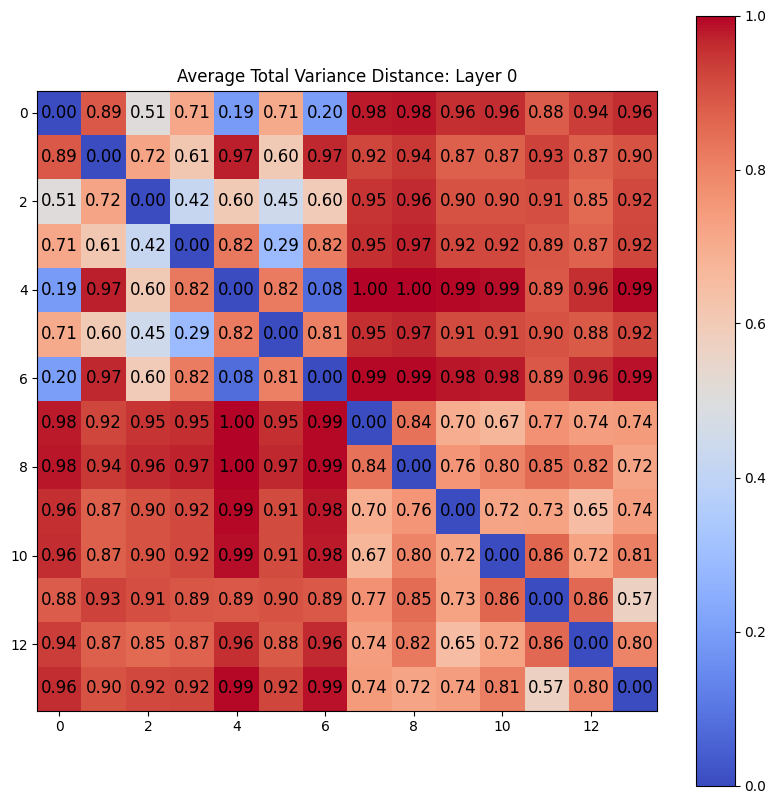

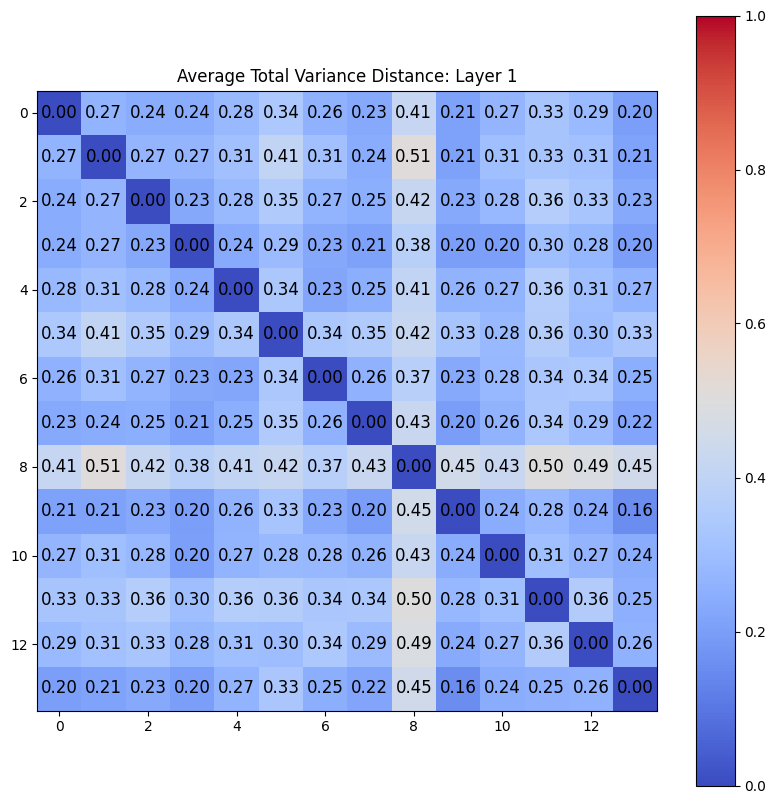

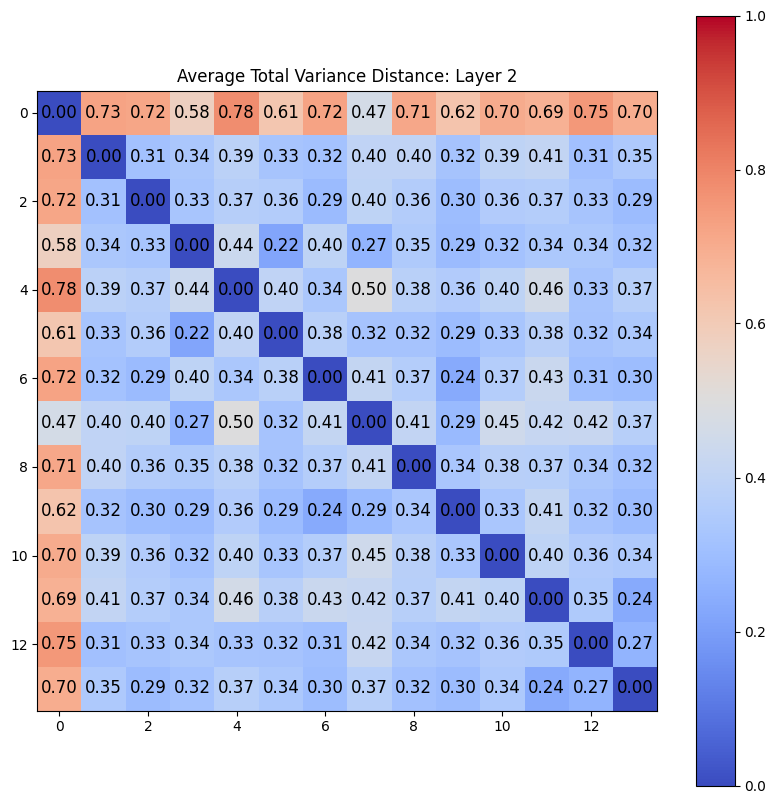

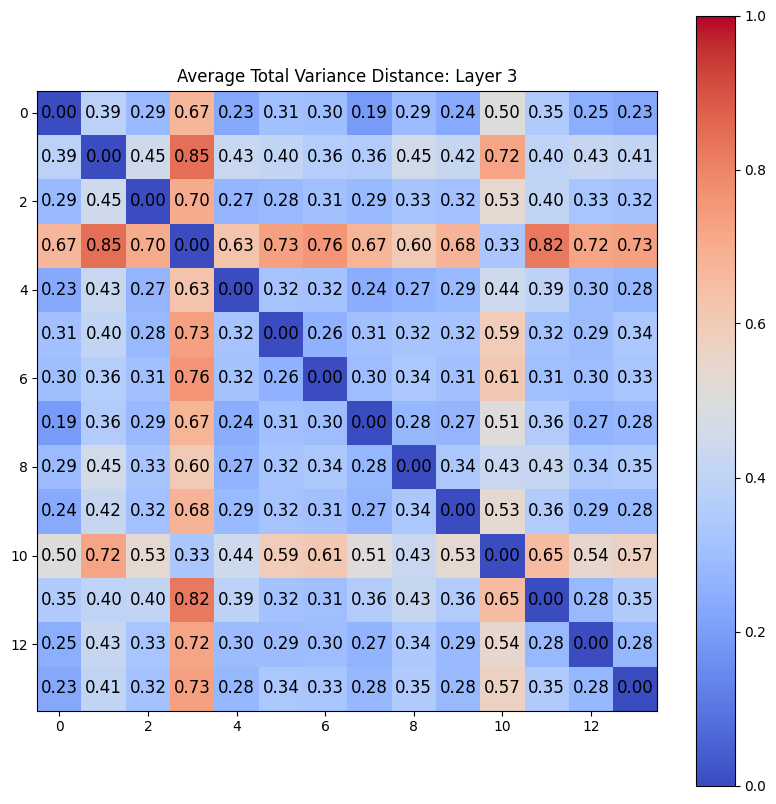

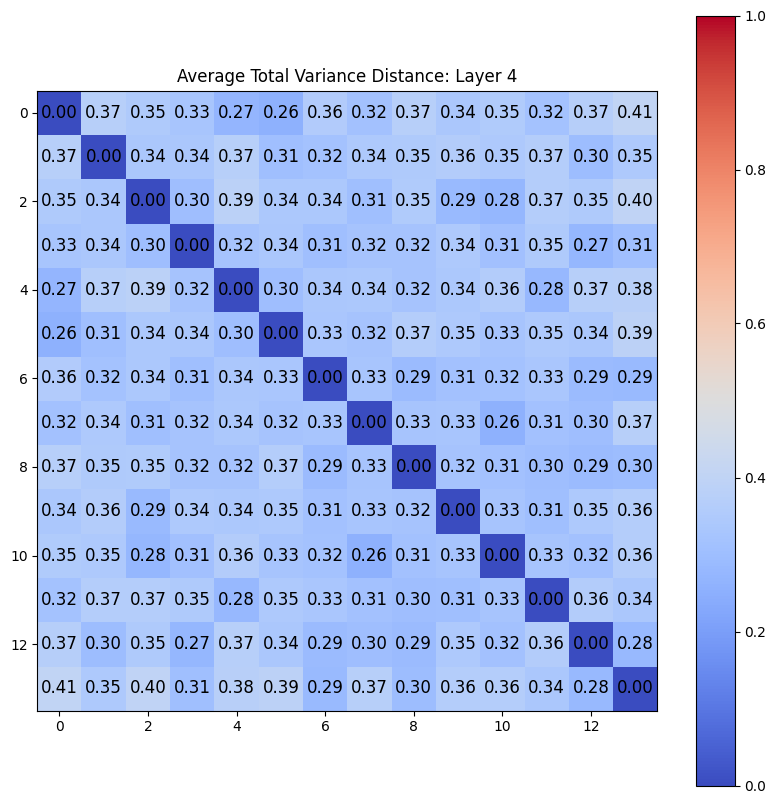

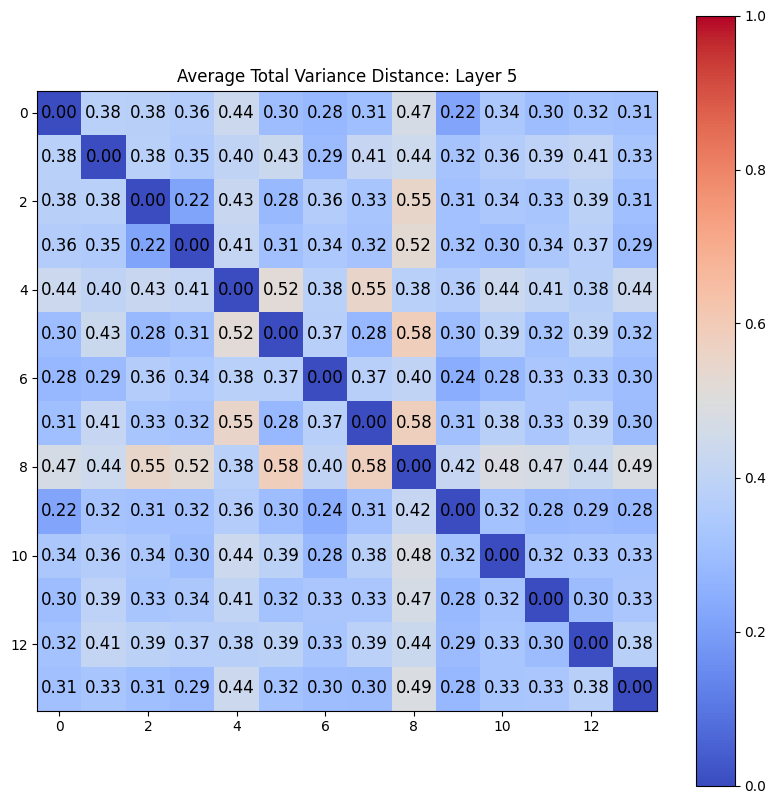

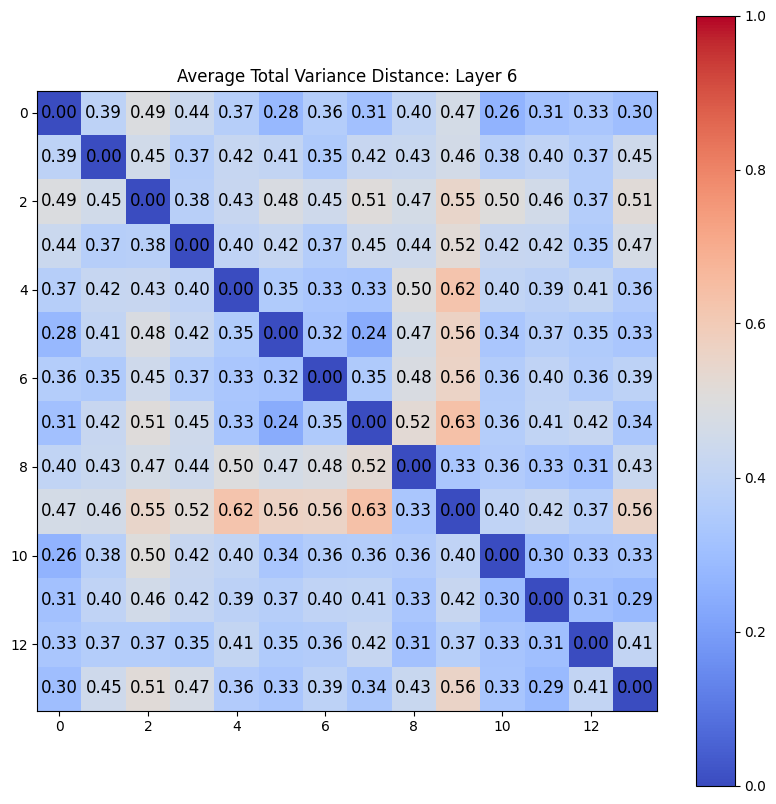

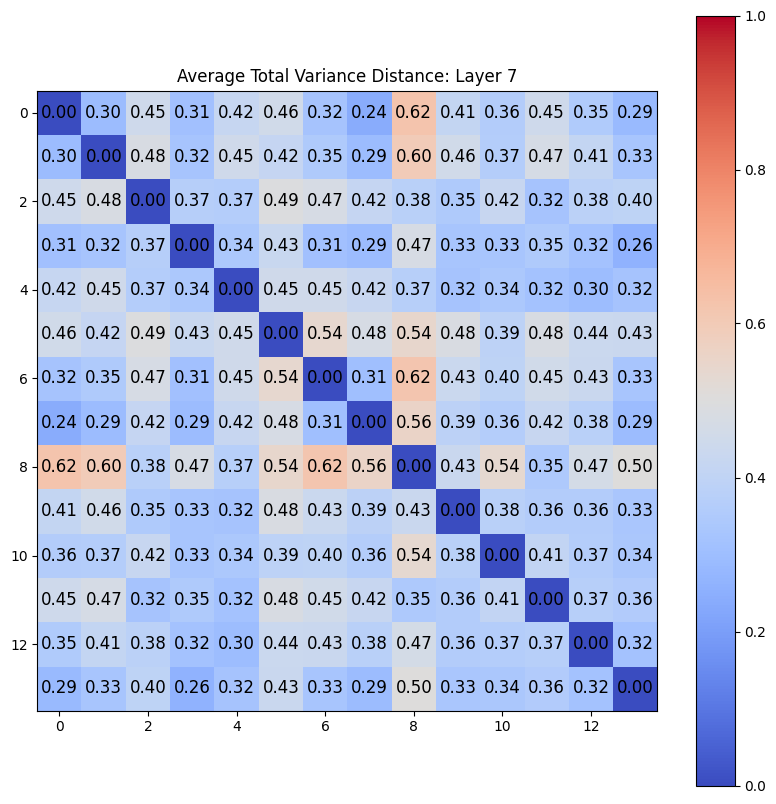

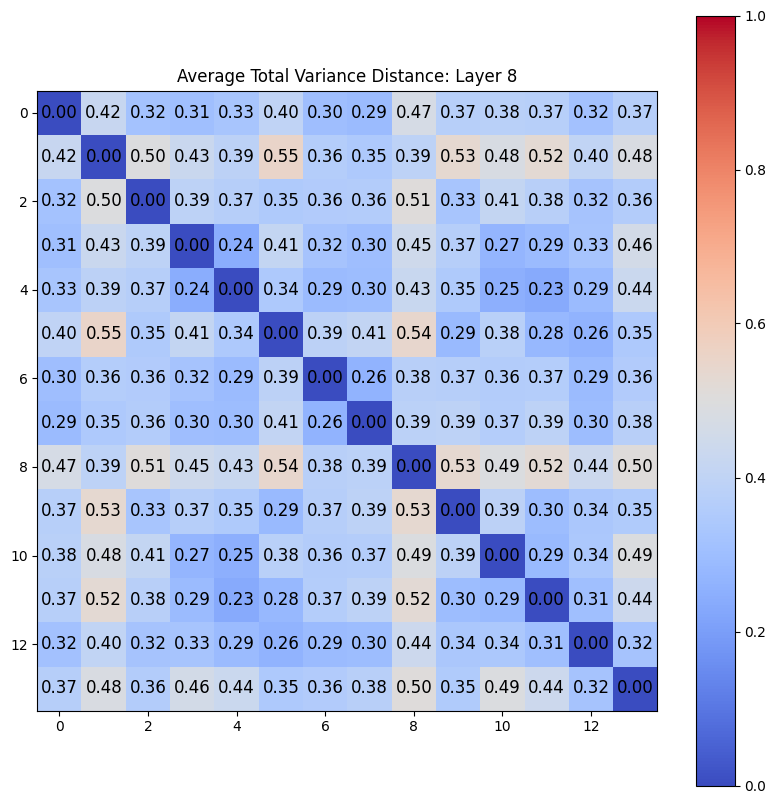

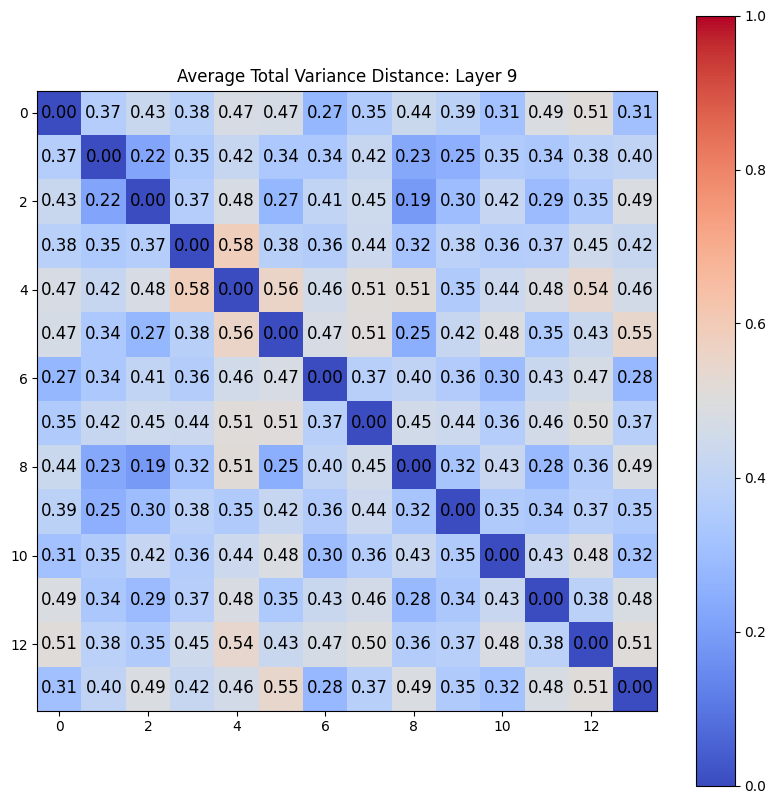

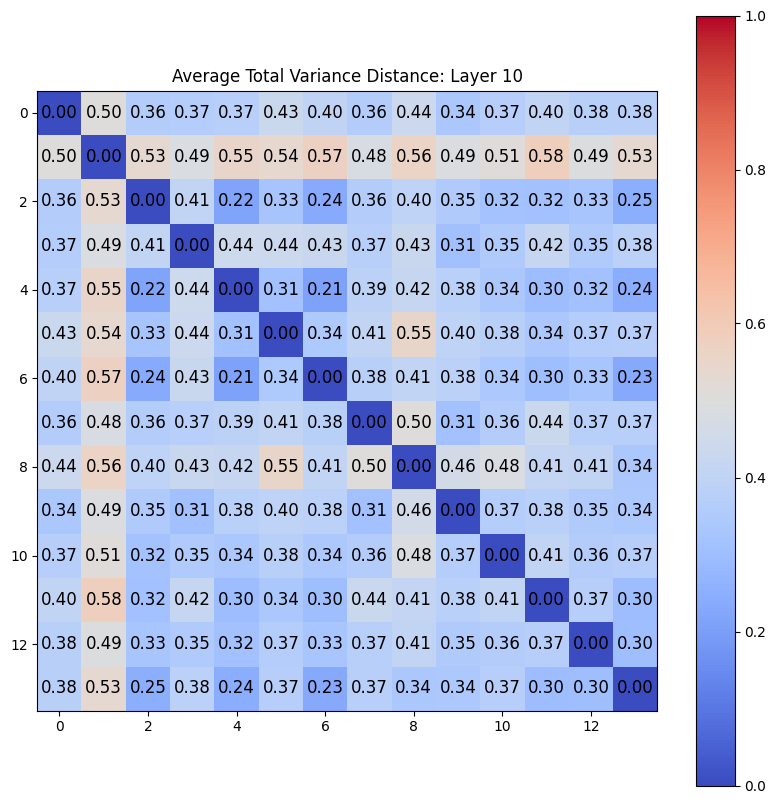

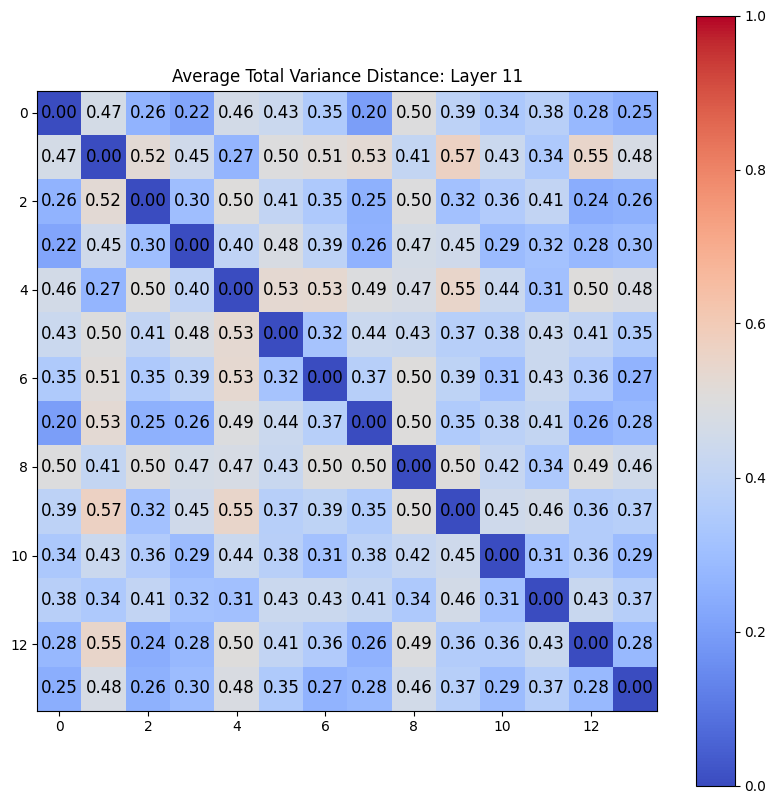

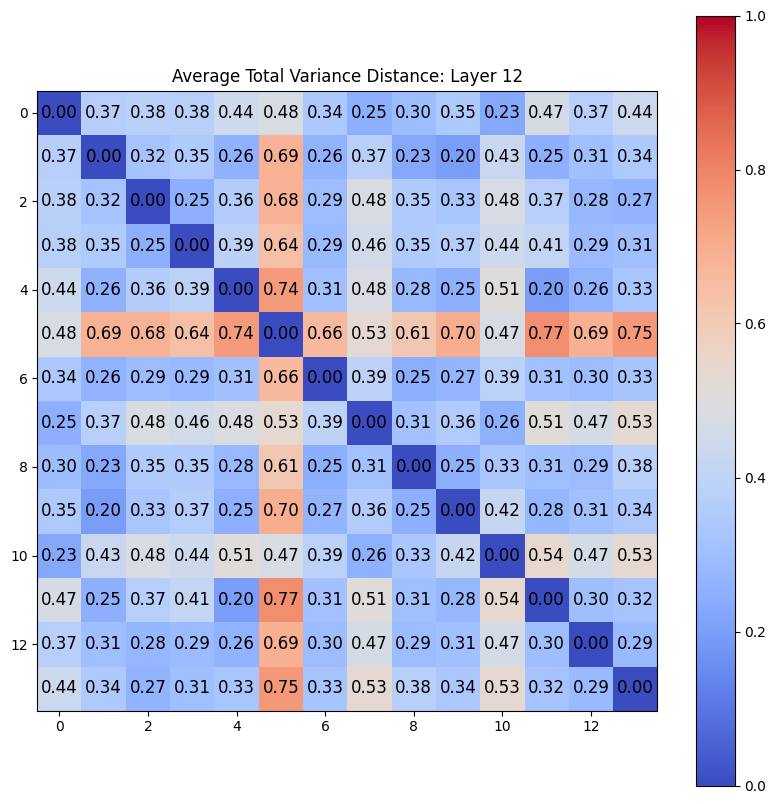

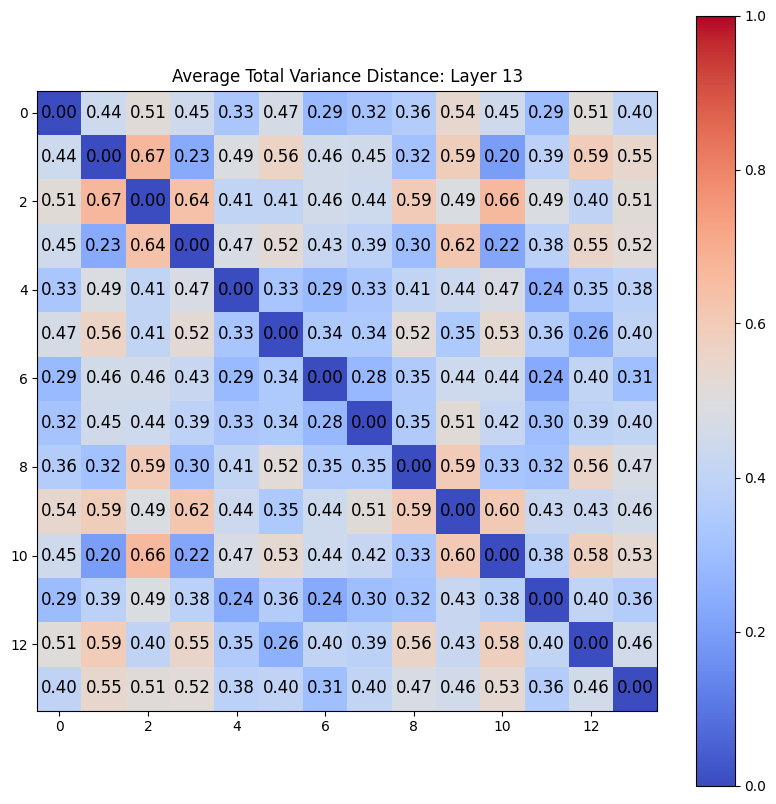

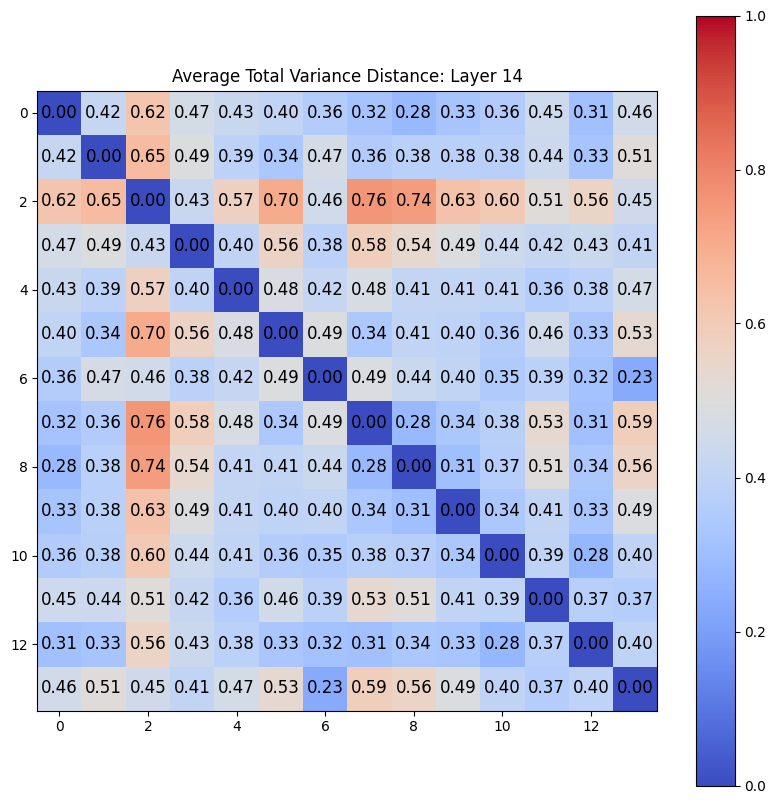

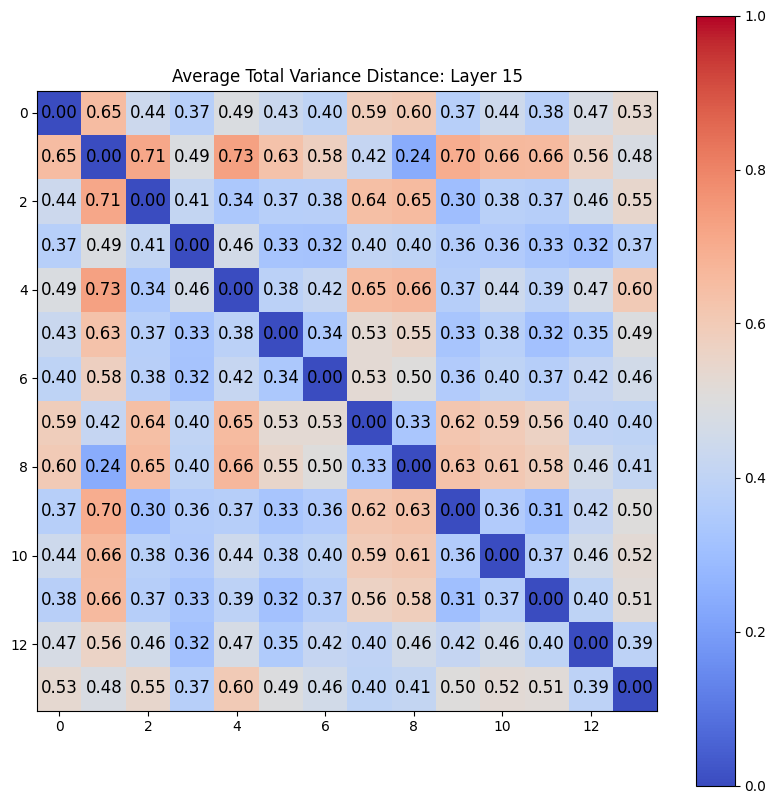

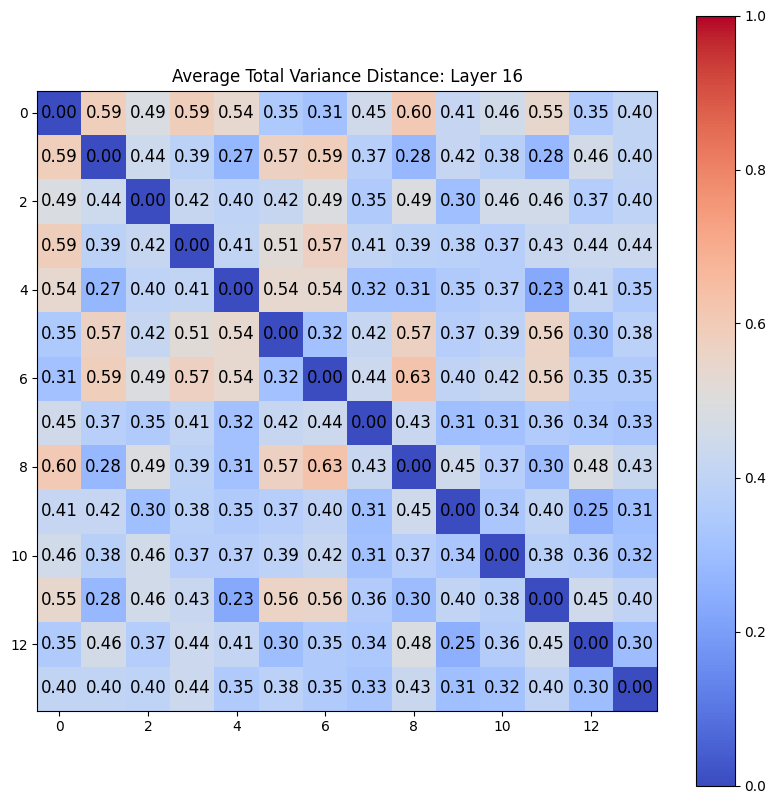

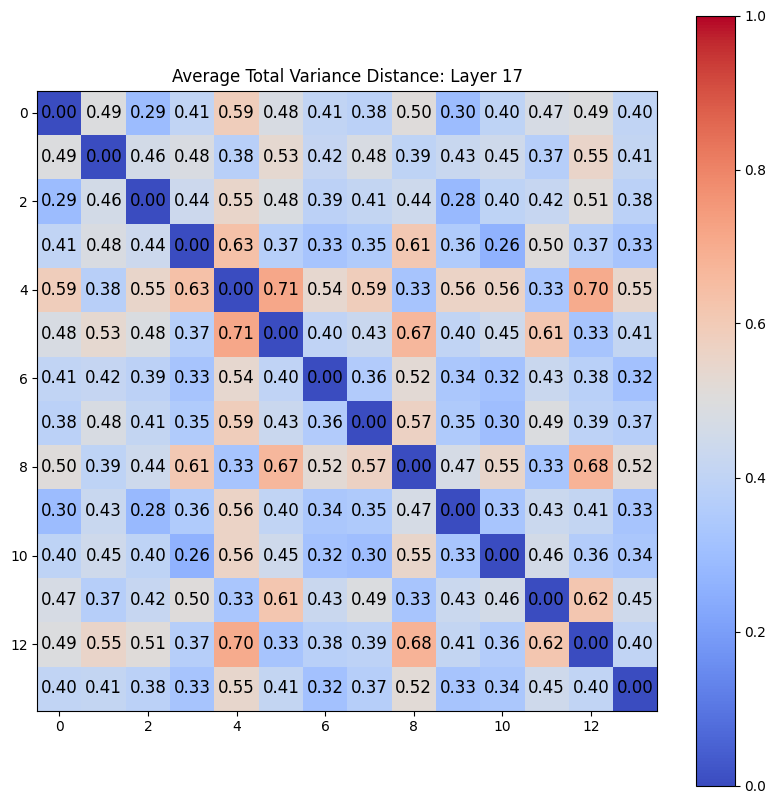

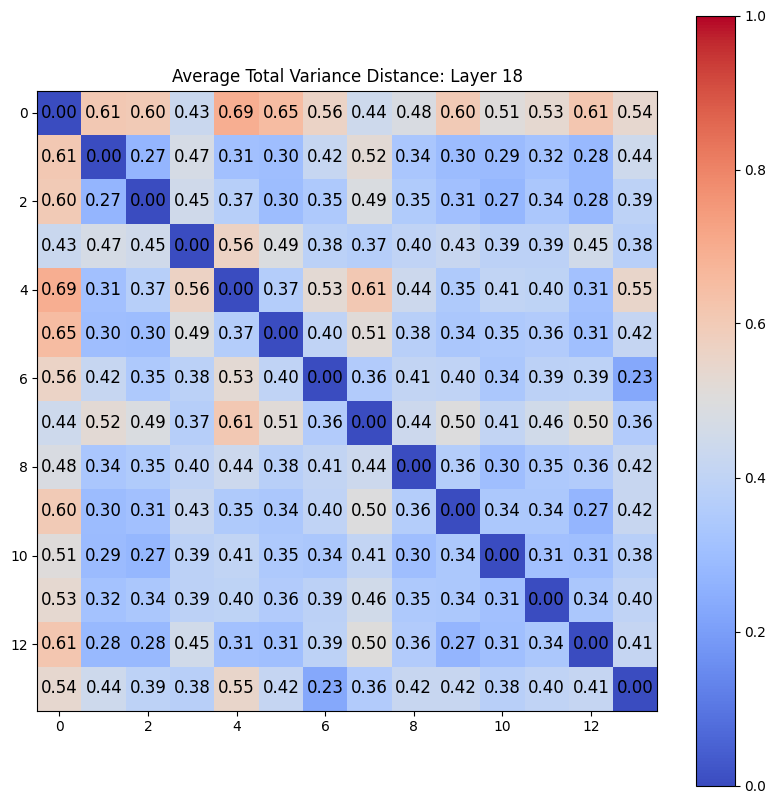

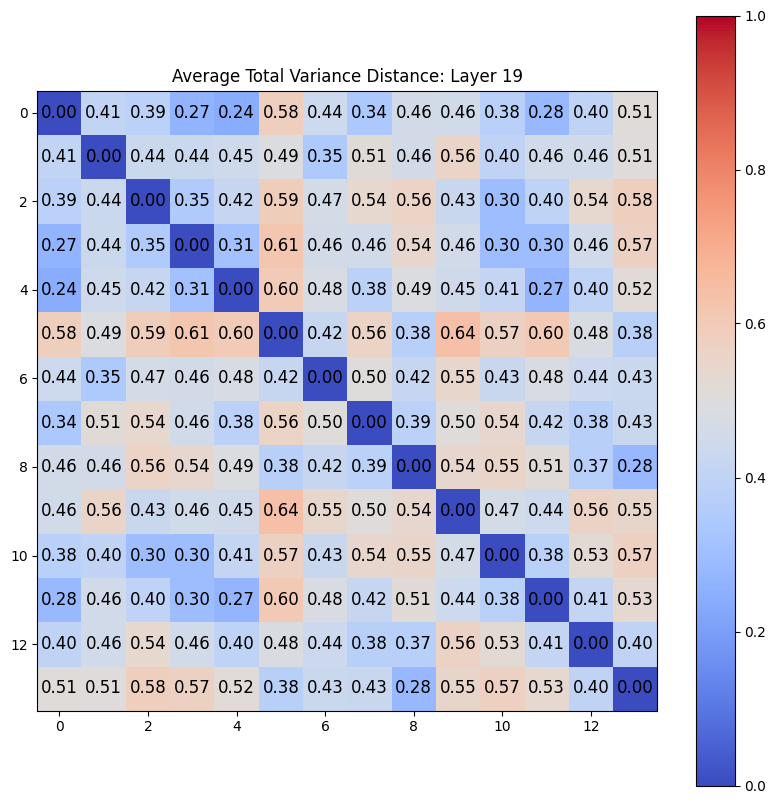

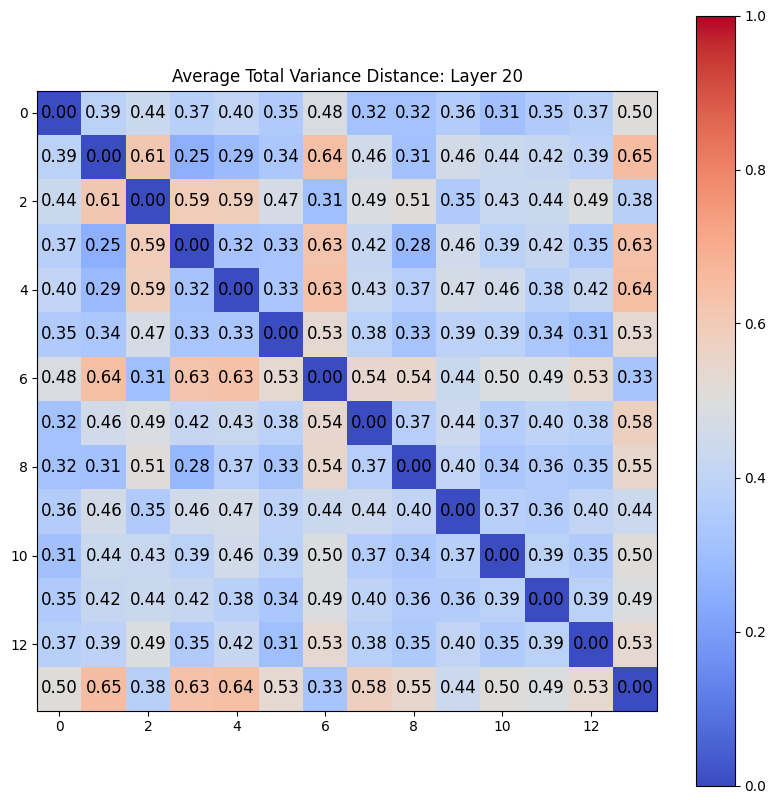

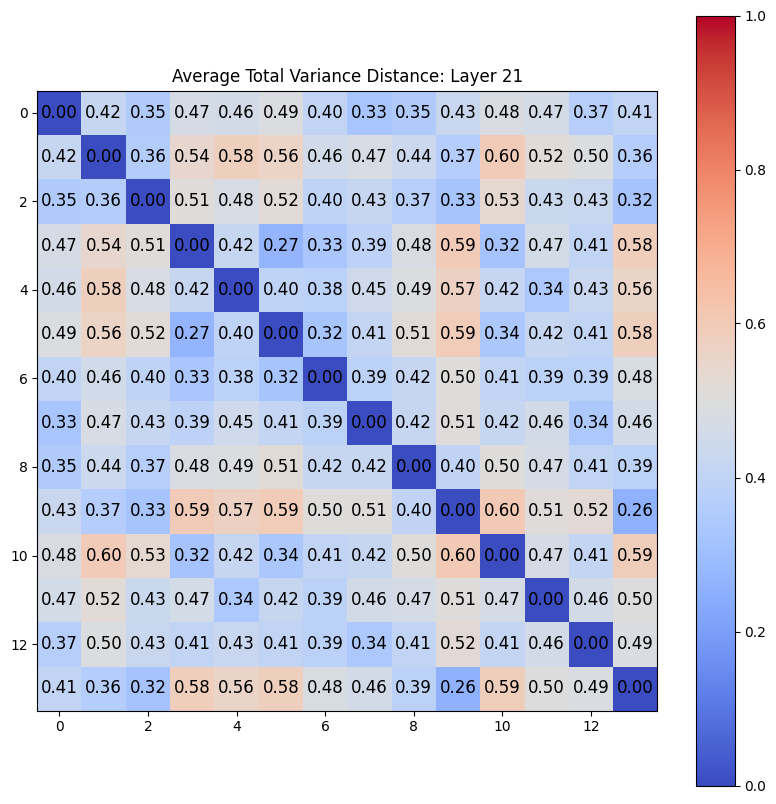

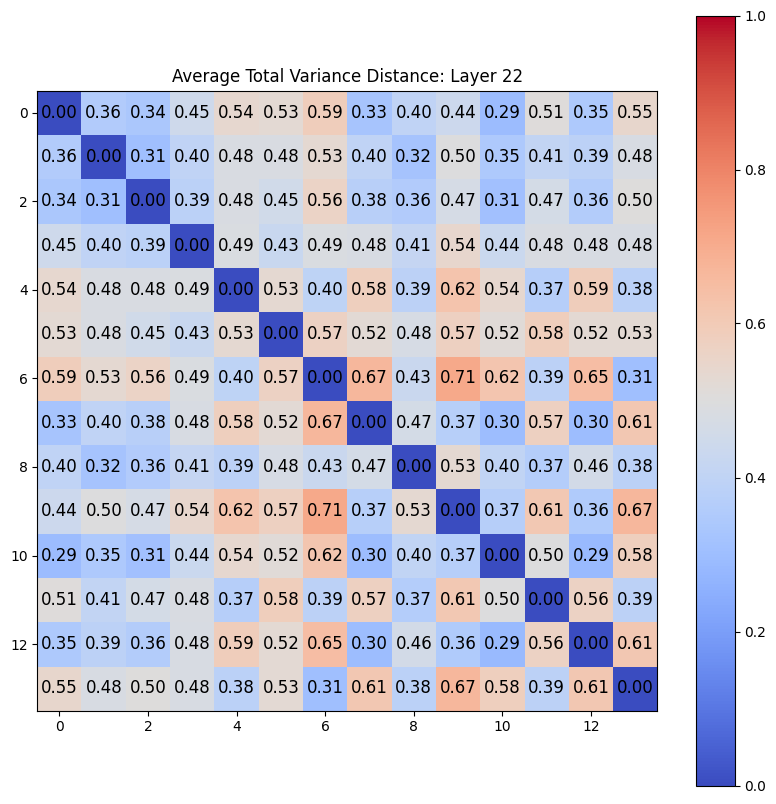

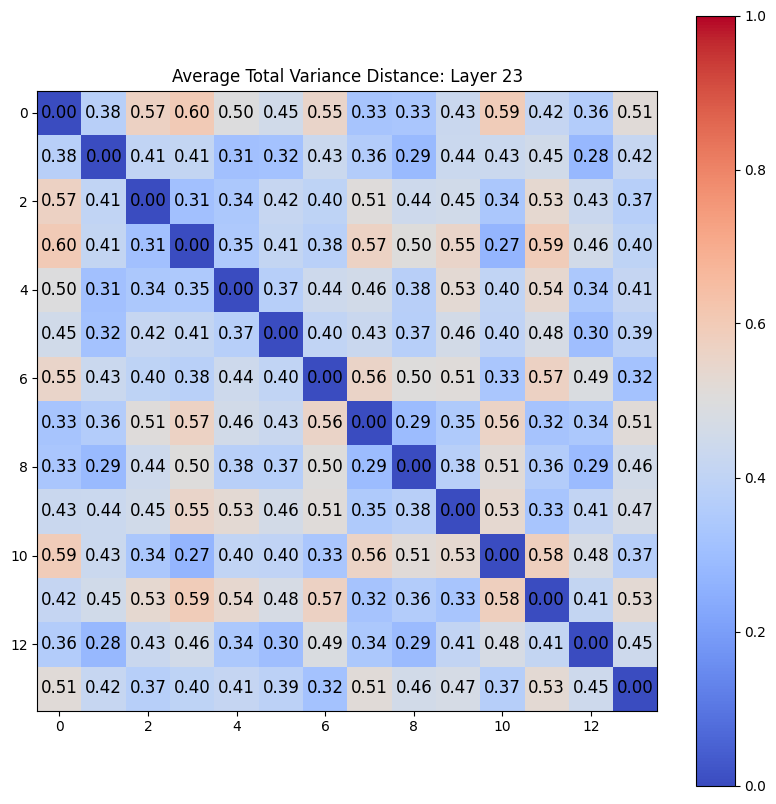

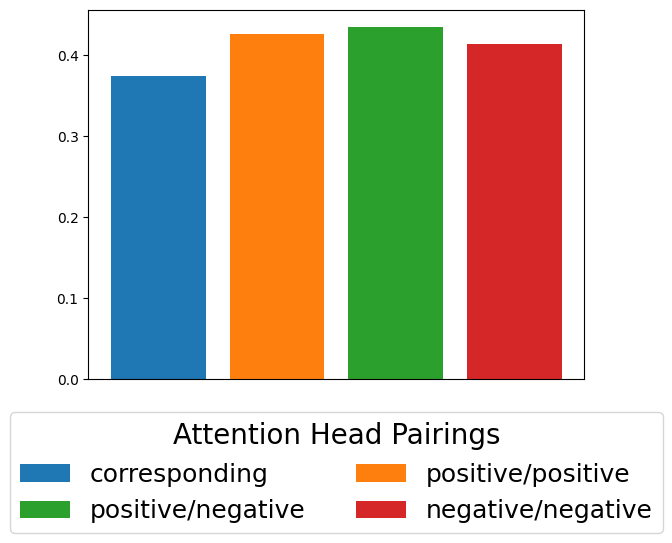

corresponding: 0.3741261661052704
positive_positive: 0.42650675773620605
positive_negative: 0.4347909688949585
negative_negative: 0.41339993476867676


In [25]:
from qwen2_better_diff_large_kv.modeling_diff_qwen2 import Qwen2ForCausalLM as Qwen2ForCausalLMBetterDiffLargeKV
from qwen2_better_diff_small_kv.modeling_diff_qwen2 import Qwen2ForCausalLM as Qwen2ForCausalLMBetterDiffSmallKV
from qwen2_diff.modeling_diff_qwen2 import Qwen2ForCausalLM as Qwen2ForCausalLMDiff

correspondings, positive_positives, positive_negatives, negative_negatives = [], [], [], []
# model_name = "qwen2_better_diff_large_kv"
for model_name in ["qwen2_diff"]:#, "qwen2_vanilla", "qwen2_better_diff_small_kv", "qwen2_better_diff_large_kv"] :
    print(model_name)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    config = AutoConfig.from_pretrained(model_name)
    if model_name == "qwen2_diff":
        model = Qwen2ForCausalLMDiff.from_pretrained(model_name, config=config)
    elif model_name == "qwen2_better_diff_small_kv":
        model = Qwen2ForCausalLMBetterDiffSmallKV.from_pretrained(model_name, config=config)
    elif model_name == "qwen2_better_diff_large_kv":
        model = Qwen2ForCausalLMBetterDiffLargeKV.from_pretrained(model_name, config=config)
    elif model_name == "qwen2_vanilla":
        model = Qwen2ForCausalLM.from_pretrained(model_name, config=config)
    else:
        raise ValueError(f"Unknown model name {model_name}")

    inputss = get_inputs(subset_1b, tokenizer)
    positive_attns, negative_attns = get_attn(model, inputss)
    token_distributions = calculate_token_distributions(positive_attns, negative_attns)
    statistical_distances = calculate_statistical_distances(token_distributions)

    corresponding, positive_positive, positive_negative, negative_negative = calculate_average_distances(statistical_distances, draw=True)
    correspondings.append(corresponding)
    positive_positives.append(positive_positive)
    positive_negatives.append(positive_negative)
    negative_negatives.append(negative_negative)

    # plot a column diagram
    # plt.title(model_name)
    # plt.bar(x=(0,1,2,3), height=(corresponding, positive_positive, positive_negative, negative_negative), color=["red", "green", "blue", "orange"])

    # corresponding = 0.0
    # positive_positive = 0.0
    # positive_negative = 0.0
    # negative_negative = 0.0
    #
    # if model_name == "qwen2_diff":
    #     corresponding = 0.3741261661052704
    #     positive_positive = 0.42650675773620605
    #     positive_negative = 0.4347909688949585
    #     negative_negative = 0.41339993476867676
    # elif model_name == "qwen2_vanilla":
    #     corresponding = 0.0
    #     positive_positive = 0.5815697312355042
    #     positive_negative = 0.0
    #     negative_negative = 0.0
    # elif model_name == "qwen2_better_diff_small_kv":
    #     corresponding = 0.2373632937669754
    #     positive_positive = 0.44765710830688477
    #     positive_negative = 0.47448602318763733
    #     negative_negative = 0.489217609167099
    # elif model_name == "qwen2_better_diff_large_kv":
    #     corresponding = 0.17783290147781372
    #     positive_positive = 0.3756486475467682
    #     positive_negative = 0.39544132351875305
    #     negative_negative = 0.40643516182899475
    # else:
    #     raise ValueError(f"Unknown model name {model_name}")
    #
    # corresponding = np.float64(corresponding)
    # positive_positive = np.float64(positive_positive)
    # positive_negative = np.float64(positive_negative)
    # negative_negative = np.float64(negative_negative)

    colors = plt.cm.tab10(range(4))
    plt.bar(("", " ", "  ", "   "), (corresponding, positive_positive, positive_negative, negative_negative), color=colors, label=("corresponding", "positive/positive", "positive/negative", "negative/negative"))

    handles, labels = plt.gca().get_legend_handles_labels()
    order = [0, 2, 1, 3]
    # print(f"handles: {handles}")
    # print(f"labels: {labels}")
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], title="Attention Head Pairings", loc="lower center", fontsize=18, title_fontsize=20, ncol=2, bbox_to_anchor=(0.5, -0.45))

    plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off

    plt.savefig(f"{model_name}.pdf", bbox_inches='tight', pad_inches=0)
    plt.show()
    print(f"corresponding: {corresponding}")
    print(f"positive_positive: {positive_positive}")
    print(f"positive_negative: {positive_negative}")
    print(f"negative_negative: {negative_negative}")





    # qwen2_diff

    # corresponding: 0.3741261661052704
    # positive_positive: 0.42650675773620605
    # positive_negative: 0.4347909688949585
    # negative_negative: 0.41339993476867676

    # qwen2_vanilla

    # corresponding: 0.0
    # positive_positive: 0.5815697312355042
    # positive_negative: 0.0
    # negative_negative: 0.0

    # qwen2_better_diff_small_kv

    # corresponding: 0.2373632937669754
    # positive_positive: 0.44765710830688477
    # positive_negative: 0.47448602318763733
    # negative_negative: 0.489217609167099

    # qwen2_better_diff_large_kv
    
    # corresponding: 0.17783290147781372
    # positive_positive: 0.3756486475467682
    # positive_negative: 0.39544132351875305
    # negative_negative: 0.40643516182899475

In [4]:
for i in range(len(correspondings)):
    print(f"corresponding {i}: {correspondings[i]}")
    print(f"positive_positive {i}: {positive_positives[i]}")
    print(f"positive_negative {i}: {positive_negatives[i]}")
    print(f"negative_negative {i}: {negative_negatives[i]}")

corresponding 0: 0.0
positive_positive 0: 0.6033125519752502
positive_negative 0: 0.0
negative_negative 0: 0.0
corresponding 1: 0.37515076994895935
positive_positive 1: 0.4271555244922638
positive_negative 1: 0.43570613861083984
negative_negative 1: 0.4146983325481415
corresponding 2: 0.23145298659801483
positive_positive 2: 0.4347856938838959
positive_negative 2: 0.46210575103759766
negative_negative 2: 0.47762489318847656
corresponding 3: 0.17839114367961884
positive_positive 3: 0.3780387341976166
positive_negative 3: 0.39771175384521484
negative_negative 3: 0.4084784984588623
